# 12 — Top-paying clients

Top 20 clients by total completed/paid amount, with a `RANK()` window function over the summed spend. Mirrors `docs/Client_Querires.md` §2.5.

In [ ]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_ANALYST_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [ ]:
query = """
SELECT
  u.id AS client_id,
  u.name,
  u.surname,
  SUM(p.amount) AS total_paid,
  COUNT(*) AS visits_paid,
  RANK() OVER (ORDER BY SUM(p.amount) DESC) AS spend_rank
FROM users u
JOIN client_payments p ON p.user_id = u.id
WHERE p.payment_status = 'completed' AND p.visit_paid = 1
GROUP BY u.id, u.name, u.surname
ORDER BY spend_rank
LIMIT 20;
"""

df = pd.read_sql(query, engine)
print(df)

    client_id                 name   surname  total_paid  visits_paid  \
0          44                Delia   Matache         9.0            3   
1           6              Freddie   Mercury         7.0            2   
2          97                  Axl      Rose         7.0            2   
3           7                Adele    Adkins         5.0            1   
4          22                Laura   Pausini         5.0            1   
5         105              diabet2     local         5.0            1   
6         106             diabet1L     LOCAL         5.0            1   
7         107              diabet2     LOCAL         5.0            1   
8         109        errorMoneyPro     local         5.0            1   
9         110      fibromialgiaPro       mac         5.0            1   
10        111      HypertensionPro   changes         5.0            1   
11        113  Test_01.04.26.14.53      User         5.0            1   
12        114  Test_01.04.26.14.55      User       

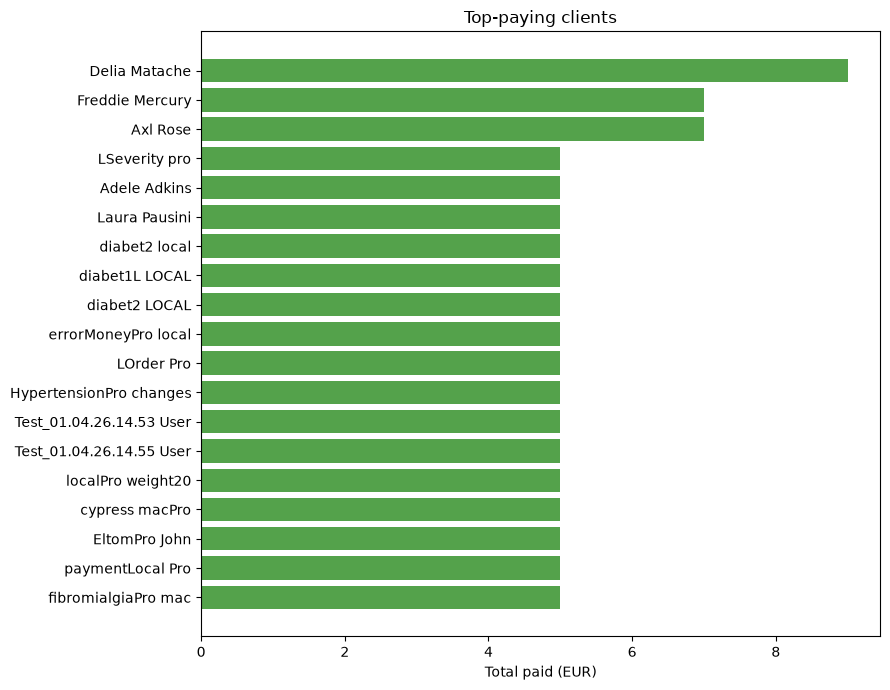

In [ ]:
%matplotlib inline
import os
import matplotlib.pyplot as plt

if df.empty:
    print("No completed payments found.")
else:
    plot_df = df.sort_values("total_paid")
    labels = plot_df["name"] + " " + plot_df["surname"]

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(plot_df))))
    ax.barh(labels, plot_df["total_paid"], color="#54A24B")
    ax.set_xlabel("Total paid (EUR)")
    ax.set_title("Top-paying clients")
    fig.tight_layout()

    os.makedirs("../assets/img", exist_ok=True)
    fig.savefig("../assets/img/top_paying_clients.png", dpi=150)
    plt.show()